In [13]:
!pip install torch torchvision matplotlib

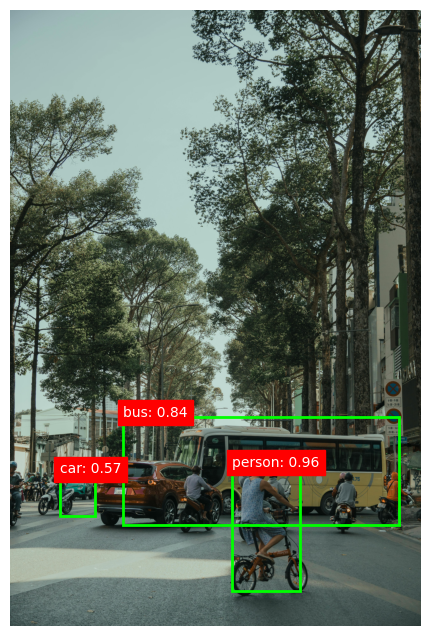

In [22]:
import torch
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# COCO class labels
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Load pretrained SSD model
model = ssdlite320_mobilenet_v3_large(pretrained=True)
model.eval()

# Image transform (no resize so boxes stay aligned)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load image
image_path = "/content/pexels-valdemarvan-21930912.jpg"  # update this path to your image
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0)

# Get predictions
with torch.no_grad():
    outputs = model(image_tensor)[0]

# Draw boxes on original image
def draw_boxes(img, boxes, labels, scores, threshold=0.5):
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    for box, label, score in zip(boxes, labels, scores):
        if score >= threshold:
            x1, y1, x2, y2 = box
            label_name = COCO_INSTANCE_CATEGORY_NAMES[label]
            color = 'lime'
            # Draw rectangle
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                     edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            # Draw label
            ax.text(x1, y1 - 5, f"{label_name}: {score:.2f}", color='white',
                    fontsize=10, backgroundcolor='red')

    plt.axis("off")
    plt.show()

draw_boxes(image, outputs['boxes'], outputs['labels'], outputs['scores'], threshold=0.5)